# ***CLEANING PHASE***

**About Dataset:**

`📊 Overview`\
This dataset is a real-world e-commerce sales data with intentional data quality issues.

`⚠️ Data Issues`
* Missing values
* Inconsistent column names
* Formatting issues
* Outliers
* Data entry errors

`🎯 Purpose`

* Data cleaning
* Exploratory Data Analysis (EDA)
* Data visualization

`❓ Question`

1. Which categories are most popular among customers, and how do they compare?
2. Do customers prefer a specific payment method or are they evenly distributed?
3. How do sales evolve over time? Are there trends or patterns?


**I - Setup**

In [1]:
import pandas as pd
import numpy as np

data = "/content/messy_ecommerce_sales_data.xlsx"
#If the data didn't want to load remove the content of the "data" variable and use ur path.
df_ = pd.read_excel(data)

df_.head()

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
0,100,Customer_100,ORD-41285,2024-11-22,Blender,Home,3,38,Cash on Delivery,Shipped,114.00
1,101,Customer_101,ORD-35783,2025-07-05,Smartphone,Electronics,2,abd,PayPal,Processing,NaN
2,102,Customer_102,ORD-84355,2024-12-23,Tennis Racket,Sports,1,389.05,PayPal,Delivered,389.05
3,103,Customer_103,ORD-57811,2025-03-19,Science,Books,5,233.92,PayPal,Processing,1169.60
4,104,Customer_104,ORD-93614,2025-10-20,Biography,Books,1,552.51,Cash on Delivery,Processing,552.51


The dataset comes with 103 rows and 11 columns.

In [2]:
df_.shape

(103, 11)

We see the columns not in usable format.

In [3]:
df_.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              103 non-null    int64  
 1    Customer_Name  103 non-null    object 
 2   Order_ID        103 non-null    object 
 3   Order_Date      103 non-null    object 
 4    Product        103 non-null    object 
 5   Category        95 non-null     object 
 6   Quantity        98 non-null     object 
 7   Price           98 non-null     object 
 8   Payment_Method  103 non-null    object 
 9   Status          103 non-null    object 
 10  Total           89 non-null     float64
dtypes: float64(1), int64(1), object(9)
memory usage: 9.0+ KB


Investigating if we have non-values.

In [4]:
df_.isna().sum()

,0
ID,0
Customer_Name,0
Order_ID,0
Order_Date,0
Product,0
Category,8
Quantity,5
Price,5
Payment_Method,0
Status,0


**II - Copy and columns fixing**

Duplicating the dataframe to maintain an unmodified reference and track changes.

In [5]:
df = df_.copy()

Fixing the columns by striping the text and title them.

In [6]:
df.columns = df.columns.str.strip().str.title()

**III - Striping object typed columns**

In [7]:
df["Customer_Name"] = df["Customer_Name"].str.strip().str.title()

In [8]:
df["Order_Id"] = df["Order_Id"].str.strip().str.upper()

In [9]:
df["Product"] = df["Product"].str.strip().str.title()

In [10]:
df["Category"] = df["Category"].str.strip().str.title()

In [11]:
df.loc[df["Category"] == "Electronic", "Category"] = "Electronics"

In [12]:
df["Payment_Method"] = df["Payment_Method"].str.strip().str.title()

In [13]:
df["Status"] = df["Status"].str.strip().str.title()

**IV - Transforming columns into numerical values**

In [14]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"], yearfirst=True, errors = "coerce")

In [15]:
df["Quantity"] = pd.to_numeric(df["Quantity"], errors = "coerce").astype("Int64")

In [16]:
df["Price"] = pd.to_numeric(df["Price"], errors = "coerce")

**V - Handling negative value**

In [17]:
df.loc[df["Quantity"] < 0, 'Quantity'] = np.nan

In [18]:
df.loc[df["Price"] < 0, 'Price'] = np.nan

In [19]:
df.loc[df["Total"] < 0, 'Total'] = np.nan

**VI - Droping duplicate**

In [20]:
df["Total"] = df["Quantity"] * df["Price"]

In [21]:
df.duplicated().sum()

np.int64(3)

In [22]:
df.drop_duplicates(inplace=True)

**VII - Results after cleaning**

In [23]:
df.head()

,Id,Customer_Name,Order_Id,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
0,100,Customer_100,ORD-41285,2024-11-22,Blender,Home,3,38.00,Cash On Delivery,Shipped,114.0
1,101,Customer_101,ORD-35783,2025-07-05,Smartphone,Electronics,2,NaN,Paypal,Processing,<NA>
2,102,Customer_102,ORD-84355,2024-12-23,Tennis Racket,Sports,1,389.05,Paypal,Delivered,389.05
3,103,Customer_103,ORD-57811,2025-03-19,Science,Books,5,233.92,Paypal,Processing,1169.6
4,104,Customer_104,ORD-93614,2025-10-20,Biography,Books,1,552.51,Cash On Delivery,Processing,552.51


After cleaning we got 100 row and 11 columns.

In [24]:
df.shape

(100, 11)

We fixed the columns format, changing the type of the columns based on their information

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100 entries, 0 to 99
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Id              100 non-null    int64         
 1   Customer_Name   100 non-null    object        
 2   Order_Id        100 non-null    object        
 3   Order_Date      97 non-null     datetime64[ns]
 4   Product         100 non-null    object        
 5   Category        92 non-null     object        
 6   Quantity        92 non-null     Int64         
 7   Price           90 non-null     float64       
 8   Payment_Method  100 non-null    object        
 9   Status          100 non-null    object        
 10  Total           83 non-null     Float64       
dtypes: Float64(1), Int64(1), datetime64[ns](1), float64(1), int64(1), object(6)
memory usage: 9.6+ KB


The amount of the non-value after cleaning.

In [26]:
df.isna().sum()

,0
Id,0
Customer_Name,0
Order_Id,0
Order_Date,3
Product,0
Category,8
Quantity,8
Price,10
Payment_Method,0
Status,0


Extracting the cleaned data.

In [27]:
df.to_excel("cleaned_ecommerce_sales_data.xlsx", index=False)

**Tip:**

`The result of the cleaned data is generall, meaning i can copy this one and start droping and adding what i want based on my needs.`

# ***ANALYSIS PHASE***

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

**1.   Which categories are most popular among customers, and how do they compare?**

In [29]:
df1 = df.copy()

In [30]:
df1.dropna(subset = "Category", inplace = True)

In [31]:
category = list(dict(df1["Category"].value_counts()).keys())
category

['Books', 'Home', 'Electronics', 'Sports', 'Clothing']

In [32]:
data1 = df1["Category"].value_counts().tolist()
data1

[22, 20, 19, 17, 14]

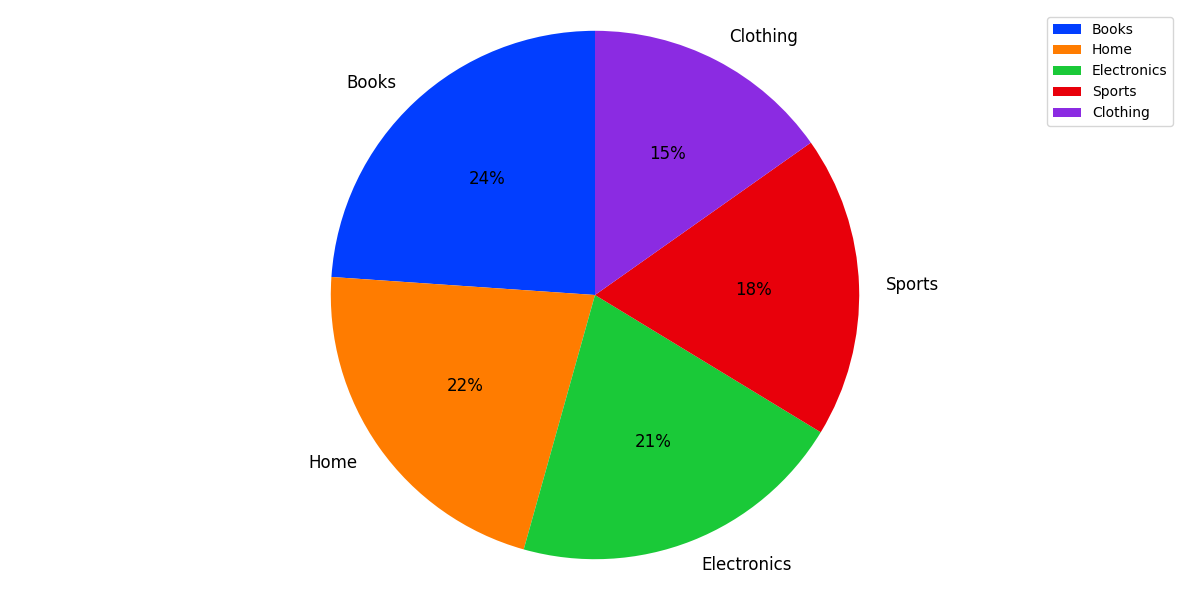

In [33]:
colors = sns.color_palette('bright')
plt.figure(figsize=(12, 6))
plt.pie(data1, labels=category, colors=colors, autopct='%.f%%', textprops={'fontsize': 12}, startangle=90)
plt.legend(category, loc='best', fontsize=10)
plt.axis('equal')
plt.tight_layout()
plt.show()

***-> Books is the most popular categories. However, the gap between Books and other categories is relatively small, indicating that sales are fairly balanced across product categories rather than dominated by a single segment.***

**2.   Do customers prefer a specific payment method or are they evenly distributed?**

In [34]:
df2 = df.copy()

In [35]:
df2.dropna(subset = "Payment_Method", inplace = True)

In [36]:
payment = list(dict(df2["Payment_Method"].value_counts()).keys())
payment

['Cash On Delivery', 'Paypal', 'Bank Transfer', 'Credit Card']

In [37]:
data2 = df2["Payment_Method"].value_counts().tolist()
data2

[33, 24, 22, 21]

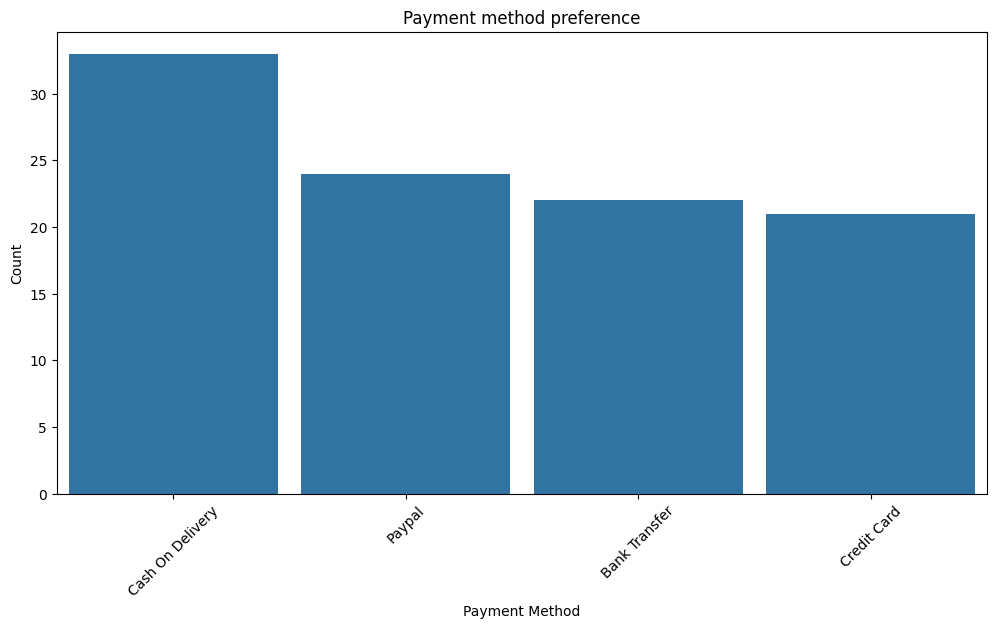

In [38]:
plt.figure(figsize=(12, 6))
sns.barplot(x = payment, y = data2, width = 0.9)
plt.title("Payment method preference")
plt.xlabel("Payment Method")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

***-> Cash on Delivery is the most commonly used payment method, suggesting that a large portion of customers prefer offline or pay-on-delivery options. The other payment methods show similar usage levels, indicating no strong secondary preference among customers.***

**3.   How do sales evolve over time? Are there trends or patterns?**

In [39]:
df3 = df.copy()
df3.dropna(subset = "Order_Date", inplace = True)
df3m = df3.copy()
df3y = df3.copy()

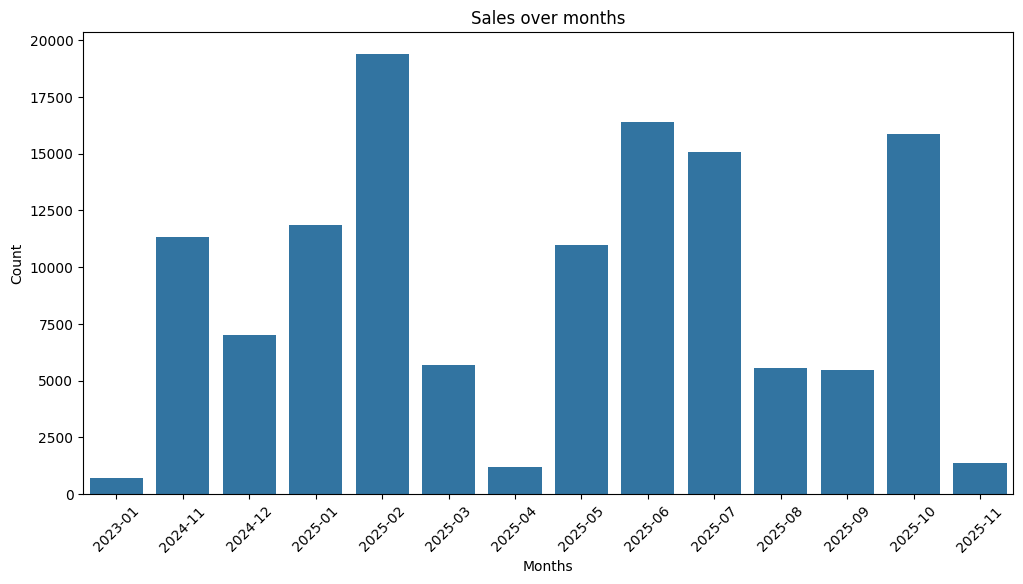

In [40]:
df3m['month'] = df3m['Order_Date'].dt.to_period('M').astype(str)

df_grouped = df3m.groupby('month', as_index=False)['Total'].sum()
plt.figure(figsize=(12, 6))
sns.barplot(data=df_grouped, x='month', y='Total')
plt.title("Sales over months")
plt.xlabel("Months")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()


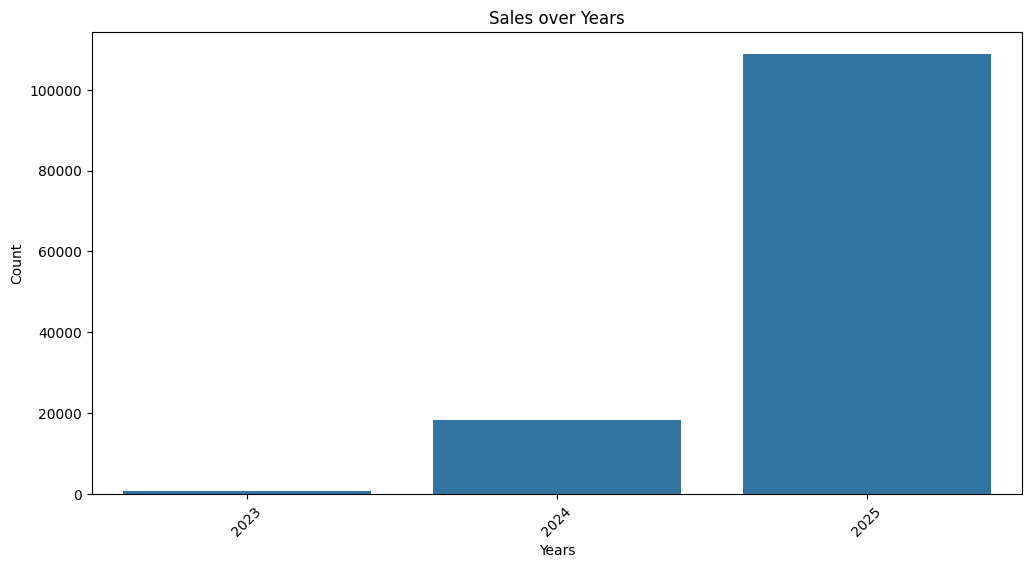

In [41]:
df3y['year'] = df3y['Order_Date'].dt.to_period('Y').astype(str)

df_grouped = df3y.groupby('year', as_index=False)['Total'].sum()
plt.figure(figsize=(12, 6))
sns.barplot(data=df_grouped, x='year', y='Total')
plt.title("Sales over Years")
plt.xlabel("Years")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

***-> The data shows some fluctuations in sales over time, with a noticeable increase around February 2025. However, the overall trend is inconsistent, with periods of growth followed by declines. This suggests the presence of short-term variations rather than a stable upward trend, and the limited data makes it difficult to identify clear long-term patterns.***

# ***CONCLUSION***

**The analysis shows that books is the most frequently ordered category, though diffrences across categories are small. Customer payment behavior is dominated by Cash on Delivery, while other methods are used at similar rates. Sales trends over time show fluctuations without a clear long-term pattern, indicating variable performance rather than consistent growth.**